In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
files = ['a1_P01.csv', 'a1_P02.csv', 'a1_P03.csv', 'a1_P04.csv', 'a1_P05.csv']

df = pd.concat([pd.read_csv(f)for f in files], ignore_index=True)
df = df[~df['trial_number'].isin([1, 5])]

# Retirando outliers mais extremos (um de cada mapping)
i_out_map1 = df[df['mapping'] == 1]['completion_time_s'].idxmax()
i_out_map2 = df[df['mapping'] == 2]['completion_time_s'].idxmax()

df_woOut = df.drop([i_out_map1, i_out_map2])

/tmp/ipykernel_69688/1813914404.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


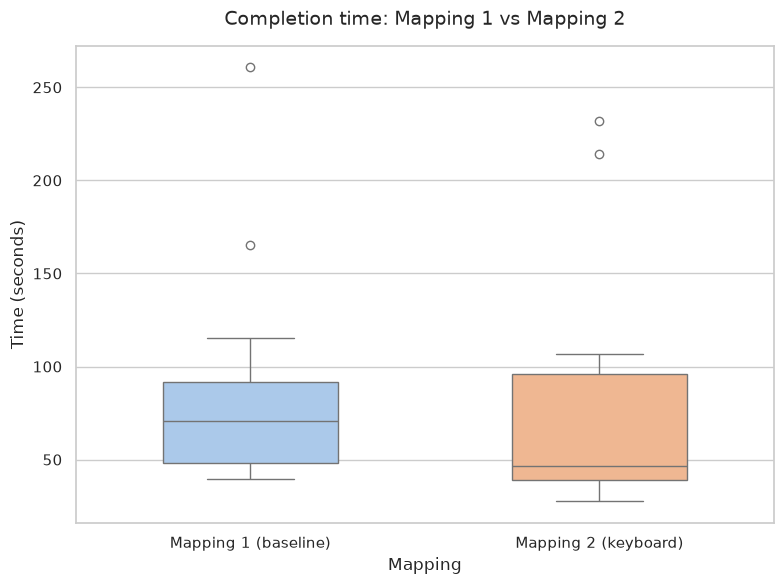

In [25]:
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=df_woOut,
    x='mapping',
    y='completion_time_s',
    width=0.5,
    palette="pastel"
)

plt.title("Completion time: Mapping 1 vs Mapping 2", fontsize=14, pad=15)
plt.xlabel("Mapping", fontsize=12)
plt.ylabel("Time (seconds)", fontsize=12)

plt.xticks(ticks=[0, 1], labels=['Mapping 1 (baseline)', 'Mapping 2 (keyboard)'])

plt.tight_layout()
plt.show()

/tmp/ipykernel_69688/2084303244.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_69688/2084303244.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


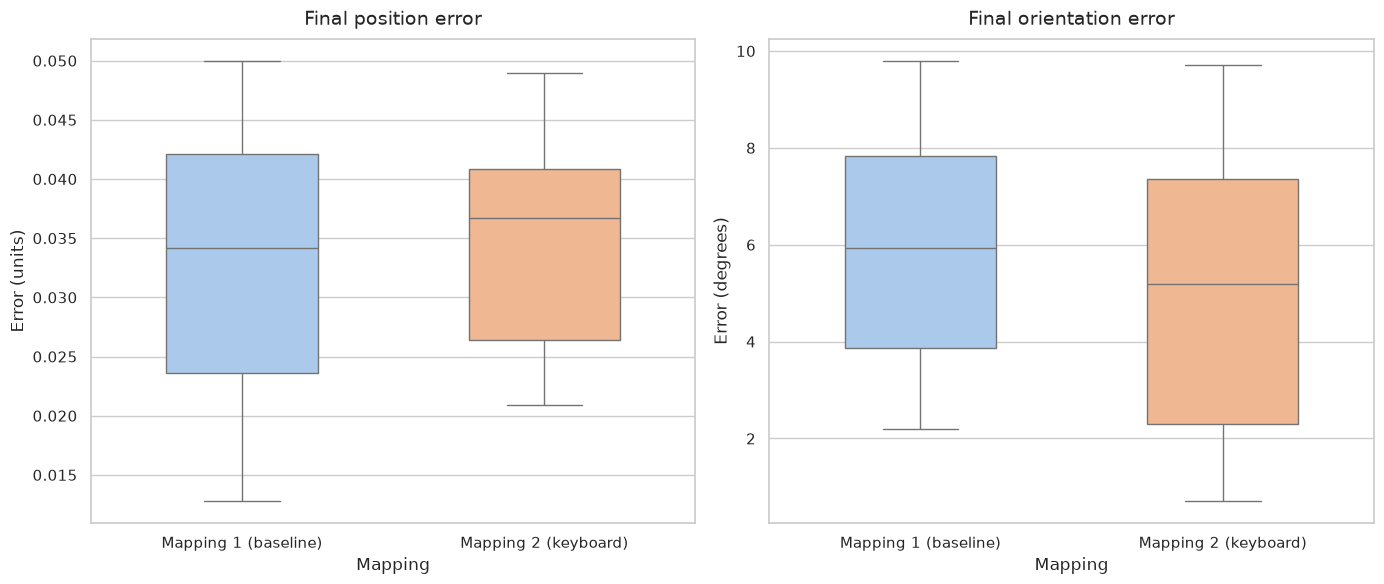

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=df, x='mapping', y='final_position_error',
    width=0.5, palette="pastel", ax=axes[0]
)

axes[0].set_title('Final position error', fontsize=14, pad=10)
axes[0].set_xlabel('Mapping', fontsize=12)
axes[0].set_ylabel('Error (units)', fontsize=12)
axes[0].set_xticks(ticks=[0, 1], labels=['Mapping 1 (baseline)', 'Mapping 2 (keyboard)'])

sns.boxplot(
    data=df, x='mapping', y='final_orientation_error_deg', 
    width=0.5, palette="pastel", ax=axes[1]
)
axes[1].set_title('Final orientation error', fontsize=14, pad=10)
axes[1].set_xlabel('Mapping', fontsize=12)
axes[1].set_ylabel('Error (degrees)', fontsize=12)
axes[1].set_xticks(ticks=[0, 1], labels=['Mapping 1 (baseline)', 'Mapping 2 (keyboard)'])

plt.tight_layout()
plt.show()

In [27]:
files = ['a1_P01.csv', 'a1_P02.csv', 'a1_P03.csv', 'a1_P04.csv', 'a1_P05.csv']

df = pd.concat([pd.read_csv(f)for f in files], ignore_index=True)

df.to_csv('experiments.csv', index=False)